# Lvlvpu Model Training

If necessary, install the required packages in `requirements.txt` via `pip`.

Make sure that the cell below loads without error message.

In [2]:
from dataclasses import dataclass
from matplotlib import font_manager
import numpy as np
import os
from PIL import Image, ImageDraw, ImageFont
import random
import torch
import torchvision.transforms as transforms


if not os.path.exists("./KuiSCIMA"):
    !git clone https://github.com/SuziAI/KuiSCIMA.git
if not os.path.exists("./gui-tools"):
    !git clone https://github.com/SuziAI/gui-tools.git

from data_extraction import *
from image_manipulation import *
from lvlvpu import *
from model import *
from stats import *

BATCH_SIZE = 100

MODEL_FOLDER = "lvlvpu_models"
if not os.path.exists(MODEL_FOLDER):
    os.mkdir(MODEL_FOLDER)

In [3]:
# Extract data from KuiSCIMA dataset
extract_data()

# Set seeds
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

# Data Augmentations for Training

In [9]:
total_dataset = open_lvlvpu_dataset("./TotalDataset/Music/")
total_dataset = get_cropped_dataset(total_dataset, remove_blobs=False)

## Normalizes the dataset to have mean 0 and standard deviation of 1
mean_list = torch.Tensor([torch.Tensor(entry["image"]).mean() for entry in total_dataset])/255
mean = mean_list.mean()
std = mean_list.std()

print(mean, std)

def normalize():
    return transforms.Normalize(mean=mean, std=std)

def get_train_transforms(image_size=48):
    target_shrink = image_size - 4
    target_paste = image_size
    train_transforms = transforms.Compose([
        erode(percentage=0.2), # causes the notation to be thicker
        dilate(percentage=0.2), # causes the notation to be thinner
        transforms.ToTensor(), # convert from uint8 to [0, 1]
        shrink(is_random=True, target_size=target_shrink),
        paste_to_square(is_random=False, target_size=target_paste),
        salt_and_pepper(percentage=0.8), # introduces salt-and-pepper-noise
        lambda img: transforms.functional.invert(img), # inverts image, needed for rotations
        transforms.RandomRotation(degrees=(-9, 9)), # randomly rotate between -12 and 12 degrees
        #lambda img: transforms.functional.invert(img), # inverts image to original color scheme
        normalize(), # normalize mean and variance
    ])
    return train_transforms


def get_validation_transforms(image_size=48):
    target_shrink = image_size - 8
    target_paste = image_size
    validation_transforms = transforms.Compose([
        transforms.ToTensor(),
        shrink(is_random=False, target_size=target_shrink),
        paste_to_square(is_random=False, target_size=target_paste),
        lambda img: transforms.functional.invert(img), # inverts image, needed for rotations
        normalize(), # normalize mean and variance
    ])
    return validation_transforms


def get_test_transforms(image_size=48):
    return get_validation_transforms(image_size=image_size)

transformations = {
    "train": get_train_transforms,
    "validation": get_validation_transforms,
    "test": get_test_transforms
}

tensor(0.7148) tensor(0.0575)


# Dataset and Dataloader functions

In [123]:
def get_distribution(dataset, num_classes, get_absolute=False):
    classes, weights = np.unique(dataset, return_counts=True)  # here, only get total dataset distribution!
    weights_dict = {}
    for cls, w in zip(classes, weights):
        weights_dict[cls] = w
    distr = []  # must pad so we get to all 17 classes
    for idx in range(num_classes):
        if idx in classes:
            distr.append(weights_dict[idx])
        else:
            distr.append(0)
    if not get_absolute:
        distr /= sum(distr)
    return distr

REAL_TOTAL_DISTRIBUTION = torch.Tensor(get_distribution([entry["annotation"] for entry in total_dataset], num_classes=17))
print(REAL_TOTAL_DISTRIBUTION)

tensor([0.0532, 0.0074, 0.0842, 0.0668, 0.0591, 0.1138, 0.0488, 0.1194, 0.0514,
        0.1037, 0.0754, 0.0529, 0.0813, 0.0015, 0.0576, 0.0015, 0.0222])


# Load Data and Make Visualization

In [124]:
total_dataloaders = get_all_dataloaders(total_dataset, transformations=transformations, is_suzipu=False)

['Noto Serif CJK JP', 'AR PL Mingti2L Big5', 'AR PL UKai CN', 'Noto Sans CJK JP']
86
{'image': array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ...,   0, 107, 255],
       [244, 163,  68, ...,   0, 109, 255],
       [ 98,  34,  89, ..., 109, 244, 255]], dtype=uint8), 'annotation': 0, 'edition': 'artificial'}
artificial dataset length 86


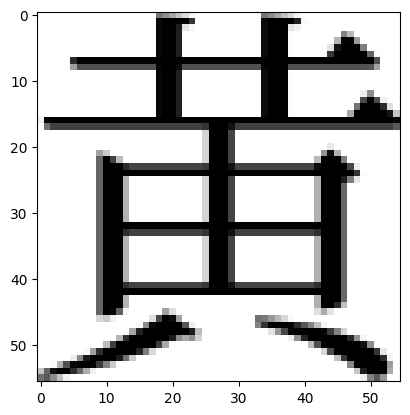

In [73]:
font_list = font_manager.get_font_names()

def is_suitable_font(name):
    do_return = False
    compounds = ["Mingti2L", "CJK", "UKai", "TW", "HK", "Songti", "Han "]
    for compound in compounds:
        do_return = do_return or compound in name
    return do_return
    
font_list = [font for font in font_list if is_suitable_font(font)]
print(font_list)

image_size = 120
augmented_dataset = []

for font in font_list: 
    for class_idx in range(len(dataclasses.astuple(ExtendedLvlv()))):
        font_path = font_manager.findfont(font)
        myFont = ImageFont.truetype(font_path, 60)
        text = ExtendedLvlv.class_to_name(class_idx)

        if "黃" in text:
            image = Image.new('RGB', (image_size, image_size), (255, 255, 255))
            I1 = ImageDraw.Draw(image)
            I1.text((0, 0), f"{text}", font=myFont, fill =(0, 0, 0))
            img_array = np.array(image.getdata()).reshape(image.size[0], image.size[1], 3)[:, :, 0]
            img_array = img_array.astype(np.uint8)
            augmented_dataset.append({"image": img_array, "annotation": class_idx, "edition": "artificial"})

            text = text.replace("黃", "黄")
            image = Image.new('RGB', (image_size, image_size), (255, 255, 255))
            I1 = ImageDraw.Draw(image)
            I1.text((0, 0), f"{text}", font=myFont, fill =(0, 0, 0))
            img_array = np.array(image.getdata()).reshape(image.size[0], image.size[1], 3)[:, :, 0]
            img_array = img_array.astype(np.uint8)
            augmented_dataset.append({"image": img_array, "annotation": class_idx, "edition": "artificial"})
        elif "清" in text:
            image = Image.new('RGB', (image_size, image_size), (255, 255, 255))
            I1 = ImageDraw.Draw(image)
            I1.text((0, 0), f"{text}", font=myFont, fill =(0, 0, 0))
            img_array = np.array(image.getdata()).reshape(image.size[0], image.size[1], 3)[:, :, 0]
            img_array = img_array.astype(np.uint8)
            augmented_dataset.append({"image": img_array, "annotation": class_idx, "edition": "artificial"})

            text = text.replace("清", "淸")
            image = Image.new('RGB', (image_size, image_size), (255, 255, 255))
            I1 = ImageDraw.Draw(image)
            I1.text((0, 0), f"{text}", font=myFont, fill =(0, 0, 0))
            img_array = np.array(image.getdata()).reshape(image.size[0], image.size[1], 3)[:, :, 0]
            img_array = img_array.astype(np.uint8)
            augmented_dataset.append({"image": img_array, "annotation": class_idx, "edition": "artificial"})
        else:
            image = Image.new('RGB', (image_size, image_size), (255, 255, 255))
            I1 = ImageDraw.Draw(image)
            I1.text((0, 0), f"{text}", font=myFont, fill =(0, 0, 0))
            img_array = np.array(image.getdata()).reshape(image.size[0], image.size[1], 3)[:, :, 0]
            img_array = img_array.astype(np.uint8)
            augmented_dataset.append({"image": img_array, "annotation": class_idx, "edition": "artificial"})

# exclude fonts that don't support the variant characters
augmented_dataset = [element for element in get_cropped_dataset(augmented_dataset, remove_blobs=False) if element["image"].shape[0] * element["image"].shape[1]]

plt.imshow(augmented_dataset[1]["image"], cmap="gray")

print(len(augmented_dataset))
print(augmented_dataset[0])

print("artificial dataset length", len(augmented_dataset))

/tmp/ipykernel_36226/2090448371.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


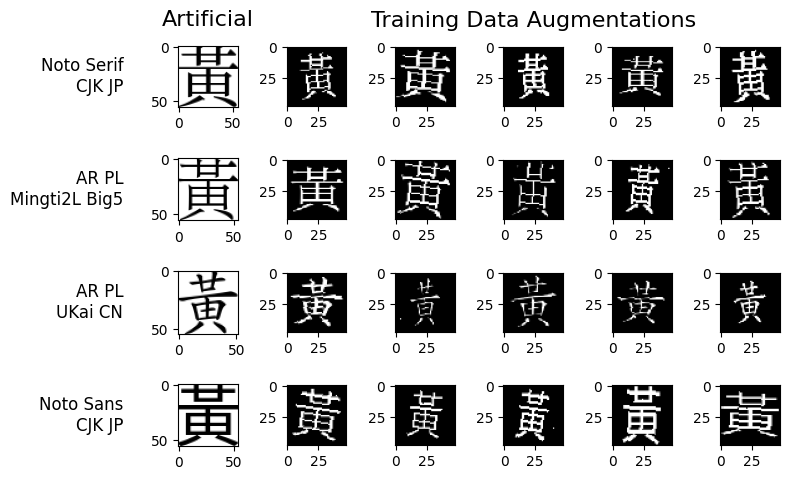

In [70]:
# take a sample and visualize some data augmentations

start_idxs = [0, 22, 42, 64]

rows, cols = 4, 6
fig, axs = plt.subplots(rows, cols, figsize=(8, 5))
fig.tight_layout()
#fig.suptitle('Horizontally stacked subplots')

fonts = ["Noto Serif\nCJK JP", "AR PL\nMingti2L Big5", "AR PL\nUKai CN", "Noto Sans\nCJK JP"]
for ax, font in zip(axs[:,0], fonts):
    ax.set_ylabel(font, rotation=0, size='large', labelpad=20, ha='right', va='center')

for row in range(rows):
    axs[row][0].imshow(augmented_dataset[start_idxs[row]]["image"], cmap="gray")

    if row == 0:
        axs[0][0].set_title("Artificial", fontsize=16, y=1.2)
        axs[0][3].set_title("Training Data Augmentations", fontsize=16, y=1.2)

    for col in range(cols-1):
        col += 1
        axs[row][col].imshow(get_train_transforms()(augmented_dataset[start_idxs[row]]["image"])[0], cmap="gray")
fig.show()
fig.tight_layout()
fig.savefig("lvlv_artificial_data.pdf", format="pdf", bbox_inches="tight")

In [74]:

total_dataloaders = get_all_dataloaders(total_dataset, transformations=transformations, is_suzipu=False, artificial_dataset=augmented_dataset)
print(len(total_dataloaders["pitch_balanced"]["train"]))
print(len(total_dataloaders["pitch_balanced"]["validation"]))
print(len(total_dataloaders["pitch_balanced"]["test"]))

total_dataloaders = get_all_dataloaders(total_dataset, transformations=transformations, is_suzipu=False)
print(len(total_dataloaders["pitch_balanced"]["train"]))
print(len(total_dataloaders["pitch_balanced"]["validation"]))
print(len(total_dataloaders["pitch_balanced"]["test"]))


22
7
7
21
7
7


/tmp/ipykernel_647474/2230466316.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


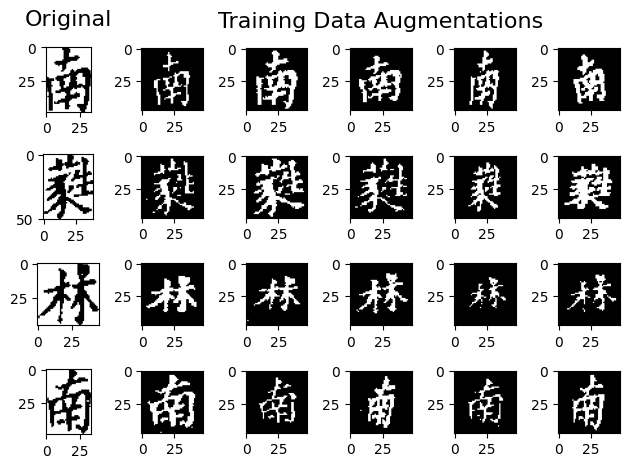

In [154]:
# take a sample and visualize some data augmentations

start_idx = 0

rows, cols = 4, 6
fig, axs = plt.subplots(rows, cols)
fig.tight_layout()
#fig.suptitle('Horizontally stacked subplots')
for row in range(rows):
    if row == 0:
        axs[0][0].set_title("Original", fontsize=16, y=1.2)
        axs[0][3].set_title("Training Data Augmentations", fontsize=16, y=1.2)
    
    axs[row][0].imshow(total_dataset[start_idx+row]["image"], cmap="gray")
        
    for col in range(cols-1):
        col += 1
        axs[row][col].imshow(get_train_transforms()(total_dataset[start_idx+row]["image"])[0], cmap="gray")
fig.show()
fig.tight_layout()
fig.savefig("lvlv_training_data_augmentations.pdf", format="pdf", bbox_inches="tight")

/tmp/ipykernel_647474/416636643.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


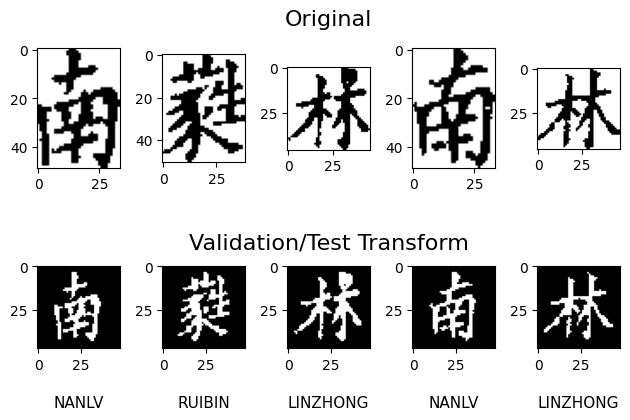

In [155]:
# take a sample and visualize some data augmentations
start_idx = 0

rows, cols = 2, 5
fig, axs = plt.subplots(rows, cols)
fig.tight_layout()
#fig.suptitle('Horizontally stacked subplots')
for row in range(rows):
    if row == 0:
        axs[0][cols//2].set_title("Original", fontsize=16, y=1.4)
        axs[1][cols//2].set_title("Validation/Test Transform", fontsize=16, y=1.1)
    
    for col in range(cols):
        axs[0][col].imshow(total_dataset[start_idx+col]["image"], cmap="gray")
        axs[1][col].imshow(get_validation_transforms()(total_dataset[start_idx+col]["image"])[0], cmap="gray")
        primary = ExtendedLvlv.from_class(total_dataset[start_idx+col]["annotation"])
        axs[1][col].set_xlabel(f'\n{primary}', size=11)

        
fig.show()
fig.tight_layout()
fig.savefig("lvlv_validation_data_augmentations.pdf", format="pdf", bbox_inches="tight")

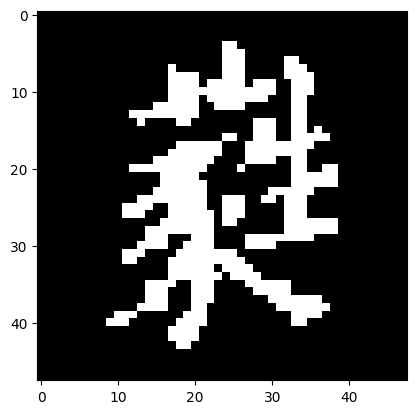

In [156]:
plt.imshow(get_validation_transforms()(total_dataset[1]["image"])[0], cmap="gray")
plt.imsave("lvlv_example.png", get_validation_transforms()(total_dataset[1]["image"])[0], cmap="gray")

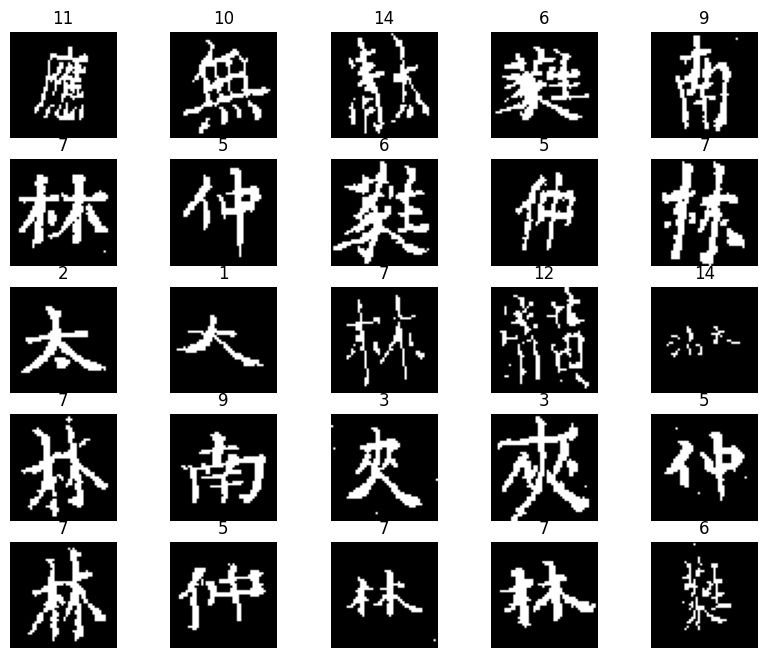

In [157]:
# visualize pitch training data (Lu edition is excluded from training data)
visualize_dataloader(total_dataloaders["none"]["train"])

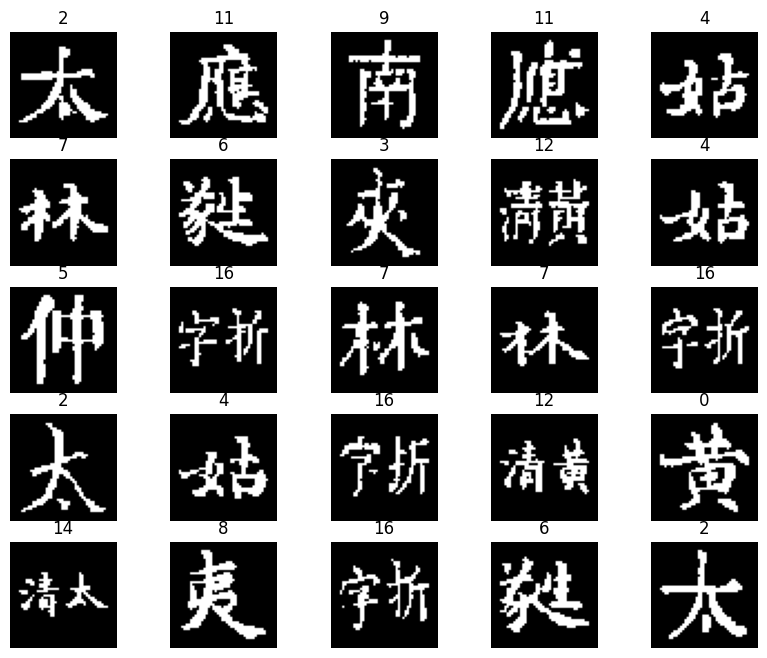

In [158]:
# visualize secondary validation data (Lu edition)
visualize_dataloader(total_dataloaders["none"]["validation"])

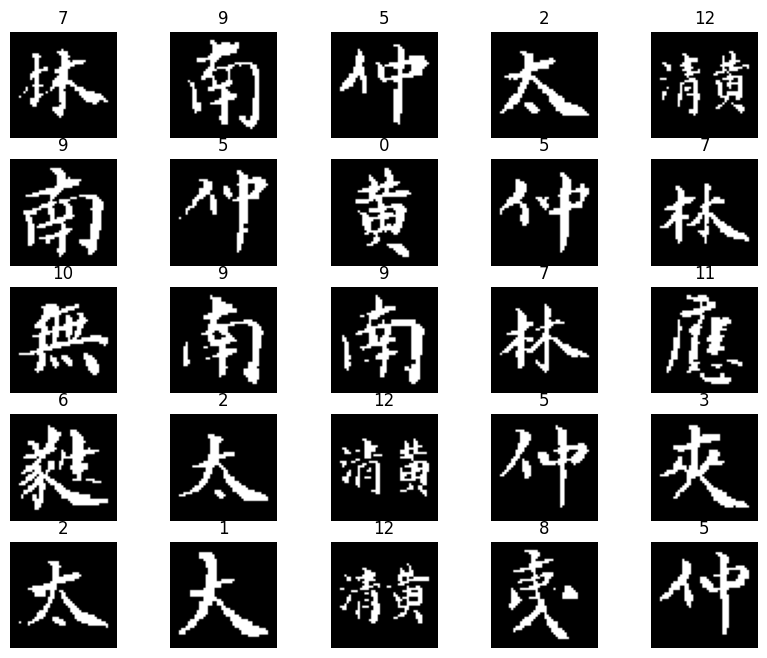

In [159]:
# visualize secondary validation data (Lu edition) - Test
visualize_dataloader(total_dataloaders["none"]["test"])

# Define Training and Validation Functions

In [80]:
from torch import optim
from torch.autograd import Variable
from torch.optim.lr_scheduler import ReduceLROnPlateau


def loss_function(x, y, gamma):
    return FocalLoss(gamma=gamma)(x, y)
    #return nn.CrossEntropyLoss(weight=torch.Tensor([1/v for v in REAL_TOTAL_DISTRIBUTION]))(x, y)


def train(num_epochs, model, loaders, do_validate=False, hyperparameters=None):
    print(hyperparameters)
    best_model = None
    max_validate = 0
    best_epoch = 0

    train_accuracies = []
    val_accuracies = []
    test_accuracies = []
    
    model.to(device)
    model.train()
        
    # Train the model
    total_step = len(loaders['train'])

    decay_params = []
    no_decay_params = []

    for name, param in model.named_parameters():
        if 'bias' in name or 'bn' in name or isinstance(param, nn.BatchNorm2d):
            no_decay_params.append(param)
        else:
            decay_params.append(param)

    if not hyperparameters:
        lr = 0.01
        weight_decay = 1e-3
        optimizer = "SGD"
        momentum = 0.9
        gamma = 3
        lr_factor = 0.8
        lr_patience = 10
        image_size = 48
    else:
        lr = hyperparameters["lr"]
        weight_decay = hyperparameters["weight_decay"]
        optimizer = hyperparameters["optimizer"]
        momentum = hyperparameters["momentum"]
        gamma = hyperparameters["gamma"]
        lr_factor = hyperparameters["lr_factor"]
        lr_patience = hyperparameters["lr_patience"]
        image_size = hyperparameters["image_size"]

    #optimizer = optim.Adam(model.parameters(), lr=0.001)
    if optimizer == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    else:
        optimizer = optim.Adam([{"params": decay_params, "weight_decay": weight_decay}, {"params": no_decay_params, "weight_decay": 0}], lr=lr, amsgrad=True)

    
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=lr_factor, patience=lr_patience)

    print(f"Training with")

    total_count_all = 0
    total_correct_all = 0

    
        
    for epoch in range(num_epochs):
        for i, (images, labels) in enumerate(loaders['train']):
            images = images.to(device)
            labels = labels.to(device)
            
            # gives batch data, normalize x when iterate train_loader
            b_x = Variable(images)   # batch x
            b_y = Variable(labels)
            
            output = model(b_x)
            
            loss = loss_function(output, b_y, gamma=gamma)
            
            # clear gradients for this training step   
            optimizer.zero_grad()
            #backpropagation, compute gradients 
            loss.backward()                # apply gradients  
            optimizer.step()
            
            pred_y = torch.argmax(output, dim=1)              
            total_accuracy = (pred_y == labels).sum() / float(len(pred_y))
            total_count_all += float(len(pred_y))
            total_correct_all += (pred_y == labels).sum()

                        
            if (i+1) % 100 == 0:
                print ('    Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}, Acc.(Total): {:.2f}%'.format(epoch + 1, num_epochs, i + 1, total_step, loss.item(), total_accuracy*100))

        print(f"Epoch {epoch+1}/{num_epochs}, Acc. (Total): {total_correct_all/total_count_all*100:.2f}%")
        current_validate, val_loss = validate(model, loaders, gamma=gamma)
        test_acc, _, _ = test(model, loaders, gamma=gamma)
        scheduler.step(val_loss)

        train_accuracies.append(total_correct_all/total_count_all)
        val_accuracies.append(current_validate)
        test_accuracies.append(test_acc)
        
        if current_validate > max_validate:
            print("***BEST MODEL***")
            best_model = copy.deepcopy(model)
            best_epoch = epoch
            max_validate = current_validate
        else:
            print(f"best model: {max_validate*100:.2f}, epoch {best_epoch}")
        best_model = copy.deepcopy(model)
                
    return best_model, best_epoch, max_validate, train_accuracies, val_accuracies, test_accuracies

def validate(model, loaders, gamma):  
    model.to(device)
    model.eval()
        
    # Train the model
    total_step = len(loaders['validation'])
    
    print(f"Validating with")
    
    pred_y = []
    full_labels = []

    val_loss = 0
        
    for i, (images, labels) in enumerate(loaders['validation']):
        images = images.to(device)
        labels = labels.to(device)

        # gives batch data, normalize x when iterate train_loader
        b_x = Variable(images)   # batch x
        b_y = Variable(labels)

        output = model(b_x)

        val_loss += loss_function(output, b_y, gamma)
        pred_y += torch.argmax(output, dim=1)
        full_labels += labels

    val_loss /= len(loaders['validation'])
    
    labels = torch.Tensor(full_labels)
    pred_y = torch.Tensor(pred_y)

    total_accuracy = (pred_y == labels).sum() / float(len(pred_y))

    print ('    Acc.(Total): {:.2f}%'.format(total_accuracy*100))
    
    return total_accuracy, val_loss

def test(model, test_loader, gamma=0):  
    model.to(device)
    model.eval()
        
    # Train the model
    total_step = len(test_loader)
    
    print(f"Testing with")
    
    pred_y = []
    full_labels = []
        
    for i, (images, labels) in enumerate(test_loader["test"]):
        images = images.to(device)
        labels = labels.to(device)

        # gives batch data, normalize x when iterate train_loader
        b_x = Variable(images)   # batch x
        b_y = Variable(labels)

        output = model(b_x)

        loss = loss_function(output, b_y, gamma)
        pred_y += torch.argmax(output, dim=1)
        full_labels += labels
    
    labels = torch.Tensor(full_labels)
    pred_y = torch.Tensor(pred_y)
    
    total_accuracy = (pred_y == labels).sum() / float(len(pred_y))

    print ('    Acc.(Total): {:.2f}%'.format(total_accuracy*100))
    
    return total_accuracy, pred_y, labels


def train_and_save_all_models(number_of_trials=10, num_epochs=10, test_edition=Editions.SHANGHAI, hyperparameters=None, offset=0, use_artificial=False):
    for artificial_dataset in [[], augmented_dataset]:
        
        num_output_classes = 17
        label_type = "none"
        
        epoch_acc_list = []
        for idx in range(number_of_trials):
            for test_edition in [Editions.LU, Editions.ZHANG, Editions.SIKU, Editions.ZHU, Editions.SHANGHAI]:
                total_dataloaders = get_all_dataloaders(total_dataset, test_edition=test_edition, image_size=hyperparameters["image_size"], transformations=transformations, artificial_dataset=artificial_dataset, is_suzipu=False)
                print(len(total_dataloaders[label_type]["train"]), len(total_dataloaders[label_type]["validation"]), len(total_dataloaders[label_type]["test"]))
                model, epoch, accuracy, train_accs, val_accs, test_accs = train(num_epochs, CnnModel(num_output_classes, hyperparameters["image_size"]), total_dataloaders[label_type], do_validate=True, hyperparameters=hyperparameters)
                test_accuracy, _, _ = test(model, total_dataloaders[label_type], gamma=hyperparameters["gamma"])
                value_dict = {
                              "state_dict": model.state_dict(), 
                              "val_accuracy": accuracy, 
                              "val_epoch": epoch, 
                              "test_accuracy": test_accuracy,
                              "train_accuracies": train_accs,
                              "val_accuracies": val_accs,
                              "test_accuracies": test_accs,
                             }

                artificial_str = "artificial" if len(artificial_dataset) else "normal"
                torch.save(value_dict, f"{MODEL_FOLDER}/{test_edition}-{artificial_str}-{idx+offset}.std")

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("DEVICE CODE IS EXECUTED ON:", device)

DEVICE CODE IS EXECUTED ON: cpu


# Train for each of the five validation settings (20% of whole data, Lu edition, ...) for each pitch and secondary symbols, and 5 times each with maximum 15 epochs. Take the epoch with the highest accuracy on the validation set.

In [167]:
hyperparameters = {
        "lr": 0.0005,
        "gamma": 1,
        "weight_decay": 1e-4,
        "lr_factor": 0.5,
        "lr_patience": 5,
        "optimizer": "Adam",
        "image_size": 48,
        "momentum": 0,
    }

model_dict = train_and_save_all_models(number_of_trials=10, num_epochs=50, hyperparameters=hyperparameters, offset=0)

22 7 7
{'lr': 0.0005, 'gamma': 1, 'weight_decay': 0.0001, 'lr_factor': 0.5, 'lr_patience': 5, 'optimizer': 'Adam', 'image_size': 48, 'momentum': 0}
Training with
Epoch 1/50, Acc. (Total): 32.80%
Validating with
    Acc.(Total): 73.71%
Testing with
    Acc.(Total): 79.32%
***BEST MODEL***
Epoch 2/50, Acc. (Total): 53.76%
Validating with
    Acc.(Total): 93.94%
Testing with
    Acc.(Total): 92.02%
***BEST MODEL***
Epoch 3/50, Acc. (Total): 64.52%
Validating with
    Acc.(Total): 94.39%
Testing with
    Acc.(Total): 94.83%
***BEST MODEL***
Epoch 4/50, Acc. (Total): 70.99%
Validating with
    Acc.(Total): 97.93%
Testing with
    Acc.(Total): 98.08%
***BEST MODEL***
Epoch 5/50, Acc. (Total): 75.70%
Validating with
    Acc.(Total): 99.26%
Testing with
    Acc.(Total): 99.11%
***BEST MODEL***
Epoch 6/50, Acc. (Total): 78.88%
Validating with
    Acc.(Total): 98.97%
Testing with
    Acc.(Total): 98.97%
best model: 99.26, epoch 4
Epoch 7/50, Acc. (Total): 81.28%
Validating with
    Acc.(Total): 

/tmp/ipykernel_36226/4170019523.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  file = torch.load(f"./{MODEL_FOLDER}/{test_edition}-{use_artificial}-{idx}.std", map_loca

tensor(0.9985)
tensor(0.9542)
[tensor(0.3176), tensor(0.5475), tensor(0.6528), tensor(0.7205), tensor(0.7638), tensor(0.7966), tensor(0.8193), tensor(0.8378), tensor(0.8533), tensor(0.8657), tensor(0.8760), tensor(0.8846), tensor(0.8919), tensor(0.8985), tensor(0.9037), tensor(0.9086), tensor(0.9130), tensor(0.9171), tensor(0.9206), tensor(0.9236), tensor(0.9257), tensor(0.9286), tensor(0.9310), tensor(0.9334), tensor(0.9356), tensor(0.9377), tensor(0.9398), tensor(0.9417), tensor(0.9435), tensor(0.9451), tensor(0.9466), tensor(0.9480), tensor(0.9495), tensor(0.9507), tensor(0.9518), tensor(0.9530), tensor(0.9541), tensor(0.9551), tensor(0.9561), tensor(0.9570), tensor(0.9579), tensor(0.9588), tensor(0.9596), tensor(0.9604), tensor(0.9611), tensor(0.9618), tensor(0.9625), tensor(0.9632), tensor(0.9638), tensor(0.9644)]
[tensor(0.9114), tensor(0.9557), tensor(0.9867), tensor(0.9867), tensor(0.9911), tensor(0.9941), tensor(0.9941), tensor(0.9956), tensor(0.9956), tensor(0.9956), tensor(0

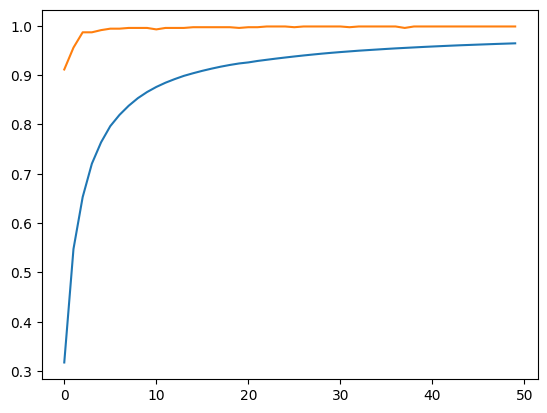

In [3]:
folder = "."
test_edition = "zhu"
use_artificial = "artificial"
idx = 0

file = torch.load(f"./{MODEL_FOLDER}/{test_edition}-{use_artificial}-{idx}.std", map_location=torch.device('cpu'))

plt.plot(file["train_accuracies"])
plt.plot(file["val_accuracies"])
print(file["val_accuracies"][-1])
print(file["test_accuracies"][-1])

print(file["train_accuracies"])
print(file["val_accuracies"])

/tmp/ipykernel_36226/1329757419.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  file = torch.load(f"./{MODEL_FOLDER}/{test_edition}-{use_artificial}-{idx}.std", map_loca

tensor(0.9970)


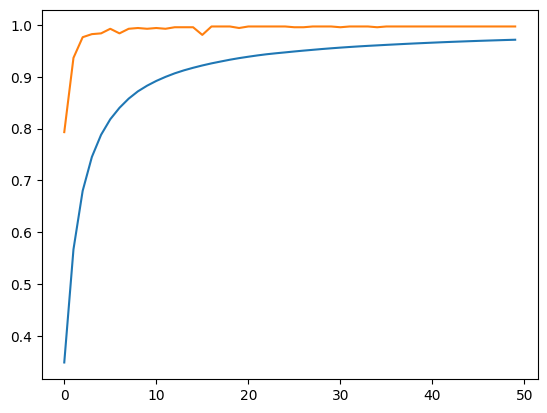

In [4]:
folder = "."
test_edition = "zhu"
use_artificial = "normal"
idx = 0

file = torch.load(f"./{MODEL_FOLDER}/{test_edition}-{use_artificial}-{idx}.std", map_location=torch.device('cpu'))

plt.plot(file["train_accuracies"])
plt.plot(file["val_accuracies"])
print(file["val_accuracies"][-1])

# Make statistics

In [90]:
def open_model_stats(folder, use_artificial, number_of_trials, validation_edition=None):
    validation_model_dict = {}
    test_model_dict = {}

    artificial_string = "artificial" if use_artificial else "normal"
    
    for test_edition in [Editions.LU, Editions.ZHANG, Editions.SIKU, Editions.ZHU, Editions.SHANGHAI]:
        validation_model_dict[test_edition] = []
        test_model_dict[test_edition] = []
        for idx in range(number_of_trials):
            file = torch.load(f"{folder}/{test_edition}-{artificial_string}-{idx}.std", map_location=torch.device('cpu'))
            validation_model_dict[test_edition].append(file["val_accuracies"][-1])
            test_model_dict[test_edition].append(file["test_accuracies"][-1])
    return validation_model_dict, test_model_dict

NUM_MODELS = 10
BEST_MODELS = 5

model_1_val_normal, model_1_test_normal = open_model_stats(MODEL_FOLDER, False, NUM_MODELS)
model_1_val_artificial, model_1_test_artificial = open_model_stats(MODEL_FOLDER, True, NUM_MODELS)

import numpy as np
from scipy.stats import pearsonr, spearmanr

highest_artificial_indices = {}
highest_normal_indices = {}
for test_edition in [Editions.LU, Editions.ZHANG, Editions.SIKU, Editions.ZHU, Editions.SHANGHAI]:
    highest_artificial_indices[test_edition] = sorted(range(len(model_1_val_artificial[test_edition])), key=lambda x: model_1_val_artificial[test_edition][x], reverse=True)[0:BEST_MODELS]
    highest_normal_indices[test_edition] = sorted(range(len(model_1_val_normal[test_edition])), key=lambda x: model_1_val_normal[test_edition][x], reverse=True)[0:BEST_MODELS]

print(model_1_val_artificial)
print(model_1_test_artificial)
print(highest_artificial_indices)

for test_edition in [Editions.LU, Editions.ZHANG, Editions.SIKU, Editions.ZHU, Editions.SHANGHAI]:
    print(test_edition)
    print("    best trial normal val", f"{model_1_val_normal[test_edition][highest_normal_indices[test_edition][0]]*100:.2f}%")
    print("    best trial artificial val", f"{model_1_val_artificial[test_edition][highest_artificial_indices[test_edition][0]]*100:.2f}%")
    print("    best trial normal", f"{model_1_test_normal[test_edition][highest_normal_indices[test_edition][0]]*100:.2f}%")
    print("    best trial artificial", f"{model_1_test_artificial[test_edition][highest_artificial_indices[test_edition][0]]*100:.2f}%")
    
print("")
print("val")
artificial_aggregated_val = np.array(list(model_1_val_artificial.values()))
normal_aggregated_val = np.array(list(model_1_val_normal.values()))
print(f"   all artificial aggregated: {artificial_aggregated_val.mean()*100:.2f} +- {artificial_aggregated_val.std()*100:.2f}")
print(f"   all normal aggregated:     {normal_aggregated_val.mean()*100:.2f} +- {normal_aggregated_val.std()*100:.2f}")
print("test")
artificial_aggregated = np.array(list(model_1_test_artificial.values()))
normal_aggregated = np.array(list(model_1_test_normal.values()))
print(f"   all artificial aggregated: {artificial_aggregated.mean()*100:.2f} +- {artificial_aggregated.std()*100:.2f}")
print(f"   all normal aggregated:     {normal_aggregated.mean()*100:.2f} +- {normal_aggregated.std()*100:.2f}")
print()

print(f"Spearman's correlation for artificial: {spearmanr(model_1_val_artificial[Editions.LU], model_1_test_artificial[Editions.ZHU])[0]}")
print(f"Spearman's correlation for normal:     {spearmanr(model_1_val_normal[Editions.LU], model_1_test_normal[Editions.ZHU])[0]}")

/tmp/ipykernel_36226/4106103764.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  file = torch.load(f"{folder}/{test_edition}-{artificial_string}-{idx}.std", map_location

{'lu': [tensor(0.9956), tensor(0.9970), tensor(0.9911), tensor(0.9970), tensor(0.9956), tensor(0.9956), tensor(0.9985), tensor(0.9970), tensor(0.9970), tensor(0.9956)], 'zhang': [tensor(0.9970), tensor(0.9970), tensor(0.9956), tensor(0.9956), tensor(0.9956), tensor(0.9970), tensor(0.9970), tensor(0.9911), tensor(0.9911), tensor(0.9970)], 'siku': [tensor(0.9956), tensor(0.9956), tensor(0.9941), tensor(0.9926), tensor(0.9970), tensor(0.9926), tensor(0.9985), tensor(0.9956), tensor(0.9911), tensor(0.9941)], 'zhu': [tensor(0.9985), tensor(0.9970), tensor(0.9970), tensor(0.9970), tensor(0.9985), tensor(0.9911), tensor(0.9941), tensor(0.9956), tensor(0.9985), tensor(0.9926)], 'shanghai': [tensor(0.9926), tensor(0.9985), tensor(0.9970), tensor(0.9956), tensor(0.9970), tensor(0.9941), tensor(0.9970), tensor(0.9970), tensor(0.9956), tensor(0.9941)]}
{'lu': [tensor(0.9970), tensor(0.9970), tensor(0.9985), tensor(0.9985), tensor(0.9926), tensor(0.9970), tensor(0.9956), tensor(0.9970), tensor(0.99

In [83]:
import time
def conduct_timing_test(num_trials):
    folder = MODEL_FOLDER
    test_edition = Editions.SHANGHAI
    use_artificial = False
    
    total_dataloaders = get_all_dataloaders(total_dataset, test_edition=test_edition, image_size=48, transformations=transformations, is_suzipu=False)

    total_times = []
    
    model = CnnModel(17)
    secondary_model = CnnModel(7)

    file = torch.load(f"./{folder}/{test_edition}-normal-{idx}.std", map_location=torch.device('cpu'))
    model.load_state_dict(file["state_dict"])

    for trial_idx in range(num_trials):
        start = time.time()
        test(model, total_dataloaders["full"])
        duration = time.time() - start
        print(duration)
        total_times.append(duration)
             
    return total_times

timing_output = conduct_timing_test(500)

/tmp/ipykernel_36226/4221720490.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  file = torch.load(f"./{folder}/{test_edition}-normal-{idx}.std", map_location=torch.devi

Testing with
    Acc.(Total): 97.64%
0.8157086372375488
Testing with
    Acc.(Total): 97.64%
0.7104108333587646
Testing with
    Acc.(Total): 97.64%
0.7263507843017578
Testing with
    Acc.(Total): 97.64%
0.6518650054931641
Testing with
    Acc.(Total): 97.64%
0.5837380886077881
Testing with
    Acc.(Total): 97.64%
0.6237132549285889
Testing with
    Acc.(Total): 97.64%
0.6095952987670898
Testing with
    Acc.(Total): 97.64%
0.6090588569641113
Testing with
    Acc.(Total): 97.64%
0.5780670642852783
Testing with
    Acc.(Total): 97.64%
0.5863358974456787
Testing with
    Acc.(Total): 97.64%
0.5777404308319092
Testing with
    Acc.(Total): 97.64%
0.5870959758758545
Testing with
    Acc.(Total): 97.64%
0.5735161304473877
Testing with
    Acc.(Total): 97.64%
0.5757317543029785
Testing with
    Acc.(Total): 97.64%
0.5662250518798828
Testing with
    Acc.(Total): 97.64%
0.536365270614624
Testing with
    Acc.(Total): 97.64%
0.5182433128356934
Testing with
    Acc.(Total): 97.64%
0.5196075439

In [87]:
print(len(total_dataloaders["full"]["test"].dataset))
print(f"Model timing: {np.array(timing_output).mean()}, +- {np.array(timing_output).std()}")

677
Model timing: 0.5263157749176025, +- 0.07435898569555392


lu
   artificial:     99.60, 0.19
   normal: 99.42, 0.17
zhang
   artificial:     99.54, 0.22
   normal: 99.41, 0.21
siku
   artificial:     99.47, 0.21
   normal: 99.41, 0.27
zhu
   artificial:     99.60, 0.25
   normal: 99.57, 0.29
shanghai
   artificial:     99.59, 0.17
   normal: 99.60, 0.24


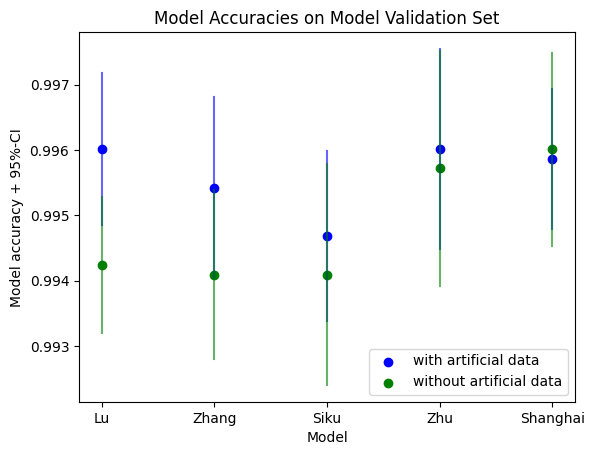

In [10]:
labels = ["Lu", "Zhang", "Siku", "Zhu", "Shanghai"]

values_artificial = get_means_and_confidences(model_1_val_artificial)
values_normal = get_means_and_confidences(model_1_val_normal)

xs = np.array(range(len(labels)))
offset = 0

for idx, test_edition in enumerate(labels):
    test_edition = test_edition.lower()
    plt.scatter(xs[idx], values_artificial[test_edition]["mean"], c="blue")
    plt.scatter(xs[idx], values_normal[test_edition]["mean"], c="green")
    plt.xticks(xs, labels)

plt.title("Model Accuracies on Model Validation Set")

plt.ylabel("Model accuracy + 95%-CI")
plt.xlabel("Model")
plt.legend(["with artificial data", "without artificial data"])

for idx, test_edition in enumerate(labels):
    test_edition = test_edition.lower()
    plt.plot((xs[idx]-offset, xs[idx]-offset),(values_artificial[test_edition]["mean"]-values_artificial[test_edition]["ci_length"], values_artificial[test_edition]["mean"]+values_artificial[test_edition]["ci_length"]),color='blue', alpha=.6)
    plt.plot((xs[idx]-offset, xs[idx]-offset),(values_normal[test_edition]["mean"]-values_normal[test_edition]["ci_length"], values_normal[test_edition]["mean"]+values_normal[test_edition]["ci_length"]),color='green', alpha=.6)
    print(test_edition)
    print(f"   artificial:     {values_artificial[test_edition]["mean"]*100:.2f}, {values_artificial[test_edition]["std"]*100:.2f}")
    print(f"   normal: {values_normal[test_edition]["mean"]*100:.2f}, {values_normal[test_edition]["std"]*100:.2f}")
#plt.plot((xs[1]-offset, xs[1]-offset),(means_artificial_art[idx]-confidence_artificial_art[idx], means_artificial_art[idx]+confidence_artificial_art[idx]),color='blue', alpha=.6)
#plt.plot((xs[1]-offset, xs[1]-offset),(means_normal_art[idx]-confidence_normal_art[idx], means_normal_art[idx]+confidence_normal_art[idx]),color='green', alpha=.6)

plt.savefig("lvlv_validation_accuracies.pdf", format="pdf", bbox_inches="tight")

lu
   artificial:     99.68, +- 0.16
   normal: 99.53, +- 0.24
zhang
   artificial:     99.70, +- 0.16
   normal: 99.42, +- 0.20
siku
   artificial:     99.45, +- 0.29
   normal: 99.31, +- 0.37
zhu
   artificial:     97.83, +- 1.26
   normal: 95.14, +- 1.94
shanghai
   artificial:     98.70, +- 0.37
   normal: 98.18, +- 0.64


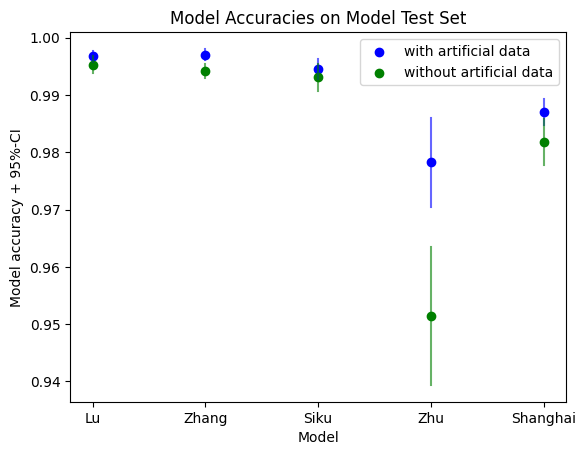

In [11]:
labels_lower = ["lu", "zhang", "siku", "zhu", "shanghai"]

values_artificial = get_means_and_confidences(model_1_test_artificial)
values_normal = get_means_and_confidences(model_1_test_normal)

labels = ["Lu", "Zhang", "Siku", "Zhu", "Shanghai"]
xs = np.array(range(len(labels)))
offset = 0

for idx, test_edition in enumerate(labels):
    test_edition = test_edition.lower()
    
    plt.scatter(xs[idx], values_artificial[test_edition]["mean"], c="blue")
    plt.scatter(xs[idx], values_normal[test_edition]["mean"], c="green")

    plt.xticks(xs, labels)

plt.title("Model Accuracies on Model Test Set")

plt.ylabel("Model accuracy + 95%-CI")
plt.xlabel("Model")
plt.legend(["with artificial data", "without artificial data"])

for idx, test_edition in enumerate(labels):
    test_edition = test_edition.lower()
    plt.plot((xs[idx]-offset, xs[idx]-offset),(values_artificial[test_edition]["mean"]-values_artificial[test_edition]["ci_length"], values_artificial[test_edition]["mean"]+values_artificial[test_edition]["ci_length"]),color='blue', alpha=.6)
    plt.plot((xs[idx]-offset, xs[idx]-offset),(values_normal[test_edition]["mean"]-values_normal[test_edition]["ci_length"], values_normal[test_edition]["mean"]+values_normal[test_edition]["ci_length"]),color='green', alpha=.6)
    print(test_edition)
    print(f"   artificial:     {values_artificial[test_edition]["mean"]*100:.2f}, +- {values_artificial[test_edition]["std"]*100:.2f}")
    print(f"   normal: {values_normal[test_edition]["mean"]*100:.2f}, +- {values_normal[test_edition]["std"]*100:.2f}")
#plt.plot((xs[1]-offset, xs[1]-offset),(means_artificial_art[idx]-confidence_artificial_art[idx], means_artificial_art[idx]+confidence_artificial_art[idx]),color='blue', alpha=.6)
#plt.plot((xs[1]-offset, xs[1]-offset),(means_normal_art[idx]-confidence_normal_art[idx], means_normal_art[idx]+confidence_normal_art[idx]),color='green', alpha=.6)

plt.savefig("lvlv_test_accuracies.pdf", format="pdf", bbox_inches="tight")

In [8]:
# Save best model
number_of_trials = 10
folder = "lvlvpu_models"
for test_edition in [Editions.LU, Editions.ZHANG, Editions.SIKU, Editions.ZHU, Editions.SHANGHAI]:
    best_accuracy = 0
    best_model = None
    for idx in range(number_of_trials):
        file = torch.load(f"{folder}/{test_edition}-artificial-{idx}.std", map_location=torch.device('cpu'))
        acc = file["val_accuracies"][-1]
        if acc > best_accuracy:
            best_model = file["state_dict"]
            best_accuracy = acc
    torch.save(best_model, f"{folder}/lvlvpu-best-{test_edition}.std")

/tmp/ipykernel_21446/3624705738.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  file = torch.load(f"{folder}/{test_edition}-artificial-{idx}.std", map_location=torch.dev